<div style="background: linear-gradient(to bottom, #28DCAA, #006EC7); padding: 24px 28px; border-radius: 12px; color: white;">

# Model Comparison — Metrics on Captioned Sample
Generates SVGs from captioned icons and computes validity, render success, and path-count metrics across model variants.

</div>

In [1]:
import gc, json, re, sys, xml.etree.ElementTree as ET
from io import BytesIO
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from PIL import Image, ImageDraw
import cairosvg

sys.path.insert(0, "..")
from brand import BRAND, blue, purple, orange, green, pink, teal, brown, white, black, dark_bg

plt.style.use("dark_background")
mpl.rcParams.update({
    "figure.facecolor": dark_bg, "axes.facecolor": blue,
    "axes.edgecolor": blue, "axes.labelcolor": white,
    "xtick.color": white, "ytick.color": white, "text.color": white,
    "legend.facecolor": dark_bg, "legend.edgecolor": blue,
})

SYSTEM_PROMPT = (
    "You are an SVG icon generator. "
    "Given a description, output clean, valid SVG code for a single icon. "
    "Use currentColor for fill and stroke so the icon inherits its parent's color. "
    "Output only the SVG element — no explanation, no markdown fences."
)

MODELS = [
    {"id": "mlx-community/Qwen2.5-Coder-7B-Instruct-4bit"},
    {"id": "mlx-community/Qwen2.5.1-Coder-7B-Instruct-4bit"},
    {"id": "mlx-community/Qwen2.5-Coder-7B-Instruct-8bit"},
    {"id": "mlx-community/Qwen2.5-Coder-14B-Instruct-4bit"},
    {"id": "mlx-community/DeepSeek-Coder-V2-Lite-Instruct-4bit"},
    {"id": "mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit"},  # ~15GB (MoE, 30B total/3B active)
]
for m in MODELS:
    m["name"] = m["id"].removeprefix("mlx-community/")

MODEL_COLORS = [orange, pink, green, teal, purple, brown]  # one color per model, Parts 1 & 2

SAMPLE_N = 50  # Part 2 only: number of captioned icons used for metrics

print("Ready. Models:", [m['name'] for m in MODELS])


Ready. Models: ['Qwen2.5-Coder-7B-Instruct-4bit', 'Qwen2.5.1-Coder-7B-Instruct-4bit', 'Qwen2.5-Coder-7B-Instruct-8bit', 'Qwen2.5-Coder-14B-Instruct-4bit', 'DeepSeek-Coder-V2-Lite-Instruct-4bit', 'Qwen3-Coder-30B-A3B-Instruct-4bit']


In [ ]:
import re

def clean_svg(raw: str) -> str:
    raw = re.sub(r'```\w*', '', raw)  # strip markdown fences
    raw = raw.replace('<|im_end|>', '')
    return raw.strip()


def generate_svgs(model_cfg: dict, prompts: list[str]) -> list[str]:
    from mlx_lm import load, generate
    from mlx_lm.sample_utils import make_sampler
    print(f"Loading {model_cfg['name']} ...")
    model, tokenizer = load(model_cfg["id"], adapter_path=model_cfg.get("adapter"))
    results = []
    for prompt in prompts:
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": prompt},
        ]
        prompt_str = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        raw = generate(model, tokenizer, prompt=prompt_str,
                       max_tokens=2048,  # 2× real-world max (~3500 chars ≈ 1000 tokens); prevents runaway without cutting valid SVGs
                       sampler=make_sampler(temp=0.7), verbose=False)
        results.append(clean_svg(raw))
    del model, tokenizer
    gc.collect()
    print(f"  done ({len(results)} icons)")
    return results


CARD_SIZE     = 200
CORNER_RADIUS = 18
ICON_PADDING  = 20

def svg_to_card(svg: str, icon_color: str, label: str = "") -> Image.Image | None:
    try:
        icon_size = CARD_SIZE - ICON_PADDING * 2
        # replace currentColor and hardcoded black (models often omit currentColor and default to black)
        svg_colored = svg.replace("currentColor", icon_color)
        svg_colored = re.sub(r'(fill|stroke)="(black|#000|#000000)"', rf'\1="{icon_color}"', svg_colored)
        png = cairosvg.svg2png(bytestring=svg_colored.encode(),
                               output_width=icon_size, output_height=icon_size)
        icon = Image.open(BytesIO(png)).convert("RGBA")

        card = Image.new("RGBA", (CARD_SIZE, CARD_SIZE), (0, 0, 0, 0))
        mask = Image.new("L", (CARD_SIZE, CARD_SIZE), 0)
        ImageDraw.Draw(mask).rounded_rectangle(
            [0, 0, CARD_SIZE - 1, CARD_SIZE - 1], radius=CORNER_RADIUS, fill=255
        )
        white = Image.new("RGBA", (CARD_SIZE, CARD_SIZE), (255, 255, 255, 255))
        card.paste(white, mask=mask)
        card.paste(icon, (ICON_PADDING, ICON_PADDING), icon)
        return card
    except Exception as e:
        tag = f" [{label}]" if label else ""
        print(f"render error{tag}: {e}")
        return None


## Part 2 — Quick Metrics on Captioned Sample

Each model generates an SVG for the first `SAMPLE_N` monochrome icons from `data/icons_captioned_sample.jsonl` (using `caption_short` as the prompt). Three lightweight metrics are computed locally:

- **VR** (Validity Rate) — % of outputs that are parseable XML with an `<svg>` root. Catches completely broken outputs.
- **RSR** (Render Success Rate) — % of valid SVGs that cairosvg can rasterize without error. Catches structurally broken but technically valid XML (e.g. unclosed paths, bad coordinates).
- **MPC** (Mean Path Count) — average number of `<path>` elements per icon, used as a proxy for visual complexity.

CLIP similarity (measuring how well the rendered icon matches its text prompt) is omitted here because it requires loading a separate vision model (~600 MB) and is slow per icon — run `06_evaluate.py` for full metrics including CLIP.

In [28]:
sample_records = []
with open("../data/icons_captioned_sample.jsonl") as f:
    for line in f:
        if not line.strip():
            continue
        r = json.loads(line)
        if not r.get("is_multicolor") and r.get("caption_short"):
            sample_records.append(r)
        if len(sample_records) >= SAMPLE_N:
            break

sample_prompts = [r["caption_short"] for r in sample_records]
print(f"Sample: {len(sample_records)} icons")
for p in sample_prompts[:5]:
    print(f"  {p}")

Sample: 50 icons
  filled number 123, simple numeric icon
  circular arrow with filled arrow, 360-degree rotation icon
  10K number in bold, black square
  10K number in a square outline
  10K number in a rounded square outline


In [29]:
def is_valid_svg(svg: str) -> bool:
    try:
        root = ET.fromstring(svg)
        return root.tag.endswith("svg")
    except ET.ParseError:
        return False

def renders_ok(svg: str) -> bool:
    try:
        cairosvg.svg2png(bytestring=svg.encode())
        return True
    except Exception:
        return False

def path_count(svg: str) -> int:
    try:
        root = ET.fromstring(svg)
        ns = root.tag.split("}")[0].lstrip("{") if "}" in root.tag else ""
        tag = f"{{{ns}}}path" if ns else "path"
        return len(root.findall(f".//{tag}"))
    except Exception:
        return 0

def compute_metrics(svgs: list[str]) -> dict:
    valid   = [is_valid_svg(s) for s in svgs]
    renders = [renders_ok(s) if v else False for s, v in zip(svgs, valid)]
    paths   = [path_count(s) for s in svgs]
    return {
        "vr":  sum(valid)   / len(svgs) * 100,
        "rsr": sum(renders) / len(svgs) * 100,
        "mpc": float(np.mean([p for p in paths if p > 0]) if any(p > 0 for p in paths) else 0),
    }


In [ ]:
metrics_results: dict[str, dict] = {}
generated_svgs:  dict[str, list[str]] = {}

for cfg in MODELS:
    svgs = generate_svgs(cfg, sample_prompts)
    generated_svgs[cfg["name"]] = svgs
    metrics_results[cfg["name"]] = compute_metrics(svgs)
    m = metrics_results[cfg["name"]]
    print(f"{cfg['name']:25s}  VR={m['vr']:.0f}%  RSR={m['rsr']:.0f}%  MPC={m['mpc']:.1f}")

Loading Qwen2.5-Coder-7B-Instruct-4bit ...


Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 124583.29it/s]


  done (50 icons)
Qwen2.5-Coder-7B-Instruct-4bit  VR=100%  RSR=100%  MPC=3.0
Loading Qwen2.5.1-Coder-7B-Instruct-4bit ...


Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 82601.17it/s]


  done (50 icons)
Qwen2.5.1-Coder-7B-Instruct-4bit  VR=100%  RSR=100%  MPC=1.0
Loading Qwen2.5-Coder-7B-Instruct-8bit ...


Fetching 10 files: 100%|██████████| 10/10 [00:00<00:00, 87018.76it/s]


  done (50 icons)
Qwen2.5-Coder-7B-Instruct-8bit  VR=100%  RSR=100%  MPC=6.4
Loading Qwen2.5-Coder-14B-Instruct-4bit ...


Fetching 10 files: 100%|██████████| 10/10 [00:00<00:00, 166440.63it/s]


In [ ]:
rows = []
for cfg in MODELS:
    m = metrics_results[cfg["name"]]
    rows.append({"Model": cfg["name"],
                 "VR (%)": f"{m['vr']:.1f}",
                 "RSR (%)": f"{m['rsr']:.1f}",
                 "MPC ↓":  f"{m['mpc']:.1f}"})

df = pd.DataFrame(rows).set_index("Model")
df

,VR (%),RSR (%),MPC ↓
Model,,,
Qwen2.5-Coder-7B,100.0,100.0,2.8


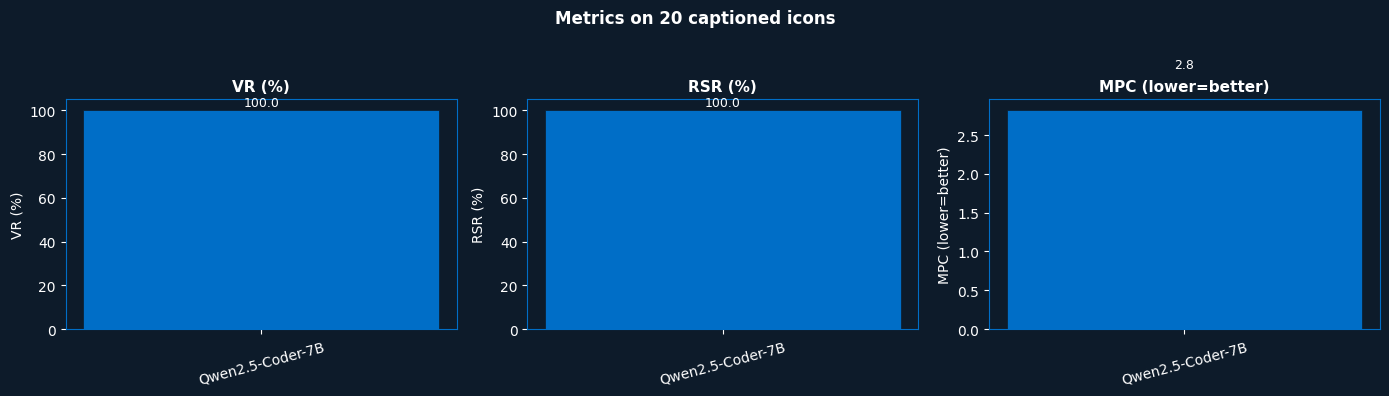

In [ ]:
metrics_keys  = ["vr", "rsr", "mpc"]
metrics_labels = ["VR (%)", "RSR (%)", "MPC (lower=better)"]
bar_colors     = [blue, purple, teal, orange, pink]
model_names    = [cfg["name"] for cfg in MODELS]
x = np.arange(len(model_names))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(14, 4), facecolor=dark_bg)

for ax, key, label in zip(axes, metrics_keys, metrics_labels):
    vals = [metrics_results[n][key] for n in model_names]
    bars = ax.bar(model_names, vals,
                  color=[bar_colors[i % len(bar_colors)] for i in range(len(model_names))],
                  edgecolor=dark_bg, linewidth=0.5)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=15)
    for spine in ax.spines.values():
        spine.set_edgecolor(blue)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.1f}", ha="center", va="bottom", fontsize=9, color=white)

plt.suptitle(f"Metrics on {SAMPLE_N} captioned icons",
             fontsize=12, color=white, fontweight="bold")
plt.tight_layout()
plt.show()